Fetching NBA team data for 2024-25 (Advanced stats).
Fetching NBA team data for 2023-24 (Advanced stats).
Fetching NBA team data for 2022-23 (Advanced stats).
Fetching NBA team data for 2021-22 (Advanced stats).
Fetching NBA team data for 2020-21 (Advanced stats).
All seasons retrieved successfully.

Original Data Snapshot:
   OFF_RATING  DEF_RATING  NET_RATING    PACE  TS_PCT  EFG_PCT  AST_RATIO  \
0       113.7       114.8        -1.1  103.41   0.579    0.546       19.9   
1       119.5       110.1         9.4   96.59   0.591    0.561       19.0   
2       108.1       115.4        -7.3   96.73   0.552    0.516       18.4   
3       106.7       115.7        -9.1   98.22   0.537    0.503       17.5   
4       113.2       114.8        -1.6  103.61   0.585    0.553       19.9   

   REB_PCT  TM_TOV_PCT    PIE  
0    0.503       0.149  0.498  
1    0.506       0.122  0.542  
2    0.487       0.156  0.452  
3    0.500       0.157  0.450  
4    0.496       0.141  0.495  
Means after scaling

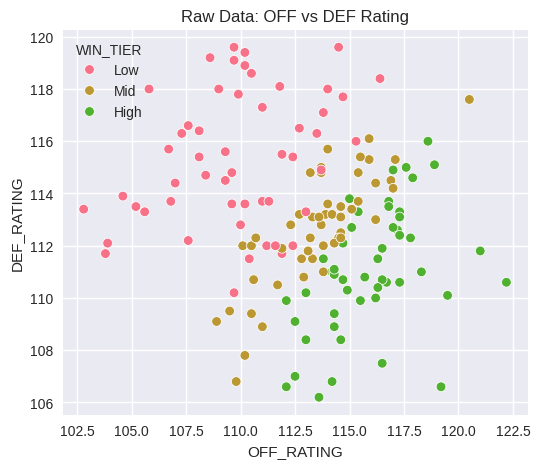

Explained variance per component: [0.50992141 0.18489739 0.1115887 ]
Total variance retained: 0.8064075062249876


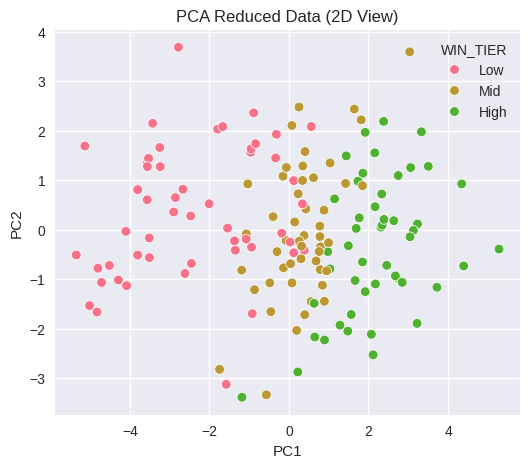

Generating Elbow Plot:


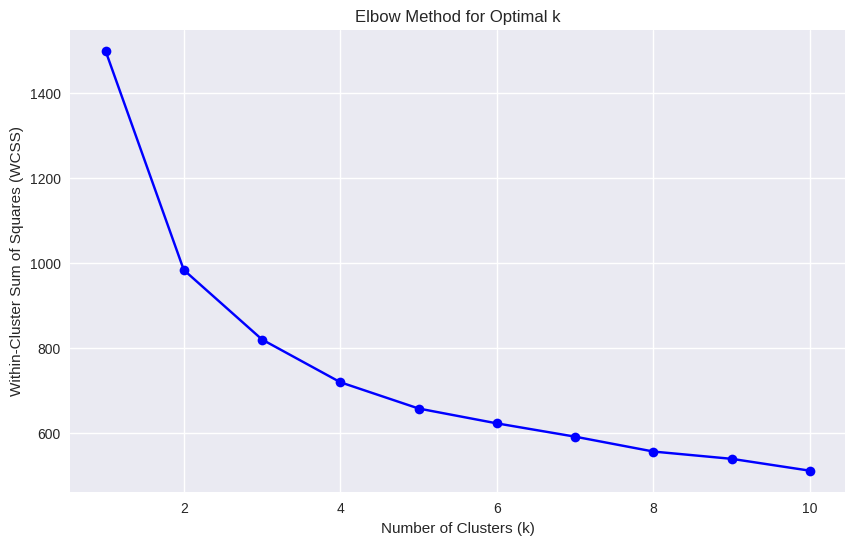

Silhouette Scores:
k=2, silhouette=0.305
k=3, silhouette=0.207
k=4, silhouette=0.198
k=5, silhouette=0.186
k=6, silhouette=0.159
k=7, silhouette=0.155


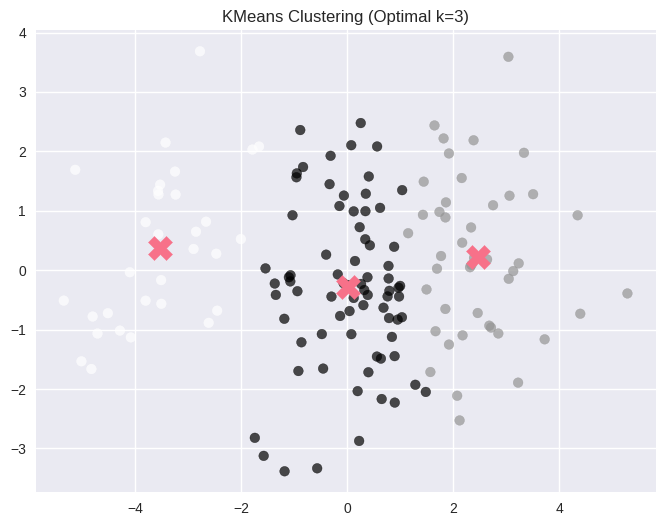

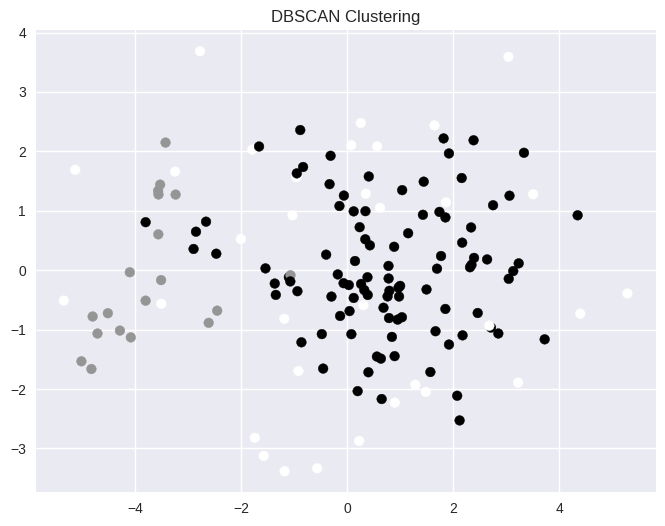

eps=1.10, min_samples=3, clusters=3, noise=141, silhouette=-0.265
eps=1.30, min_samples=3, clusters=9, noise=107, silhouette=-0.220
eps=1.50, min_samples=3, clusters=7, noise=71, silhouette=-0.082
eps=1.50, min_samples=4, clusters=5, noise=83, silhouette=-0.033
eps=1.50, min_samples=5, clusters=2, noise=107, silhouette=-0.061
eps=1.50, min_samples=6, clusters=3, noise=119, silhouette=-0.157
eps=1.70, min_samples=3, clusters=4, noise=34, silhouette=0.034
eps=1.70, min_samples=4, clusters=4, noise=39, silhouette=-0.037
eps=1.70, min_samples=5, clusters=2, noise=66, silhouette=0.081
eps=1.70, min_samples=6, clusters=2, noise=69, silhouette=0.067
eps=1.90, min_samples=3, clusters=2, noise=23, silhouette=0.051
eps=1.90, min_samples=4, clusters=3, noise=28, silhouette=0.114
eps=1.90, min_samples=5, clusters=2, noise=33, silhouette=0.154
eps=1.90, min_samples=6, clusters=2, noise=39, silhouette=0.131


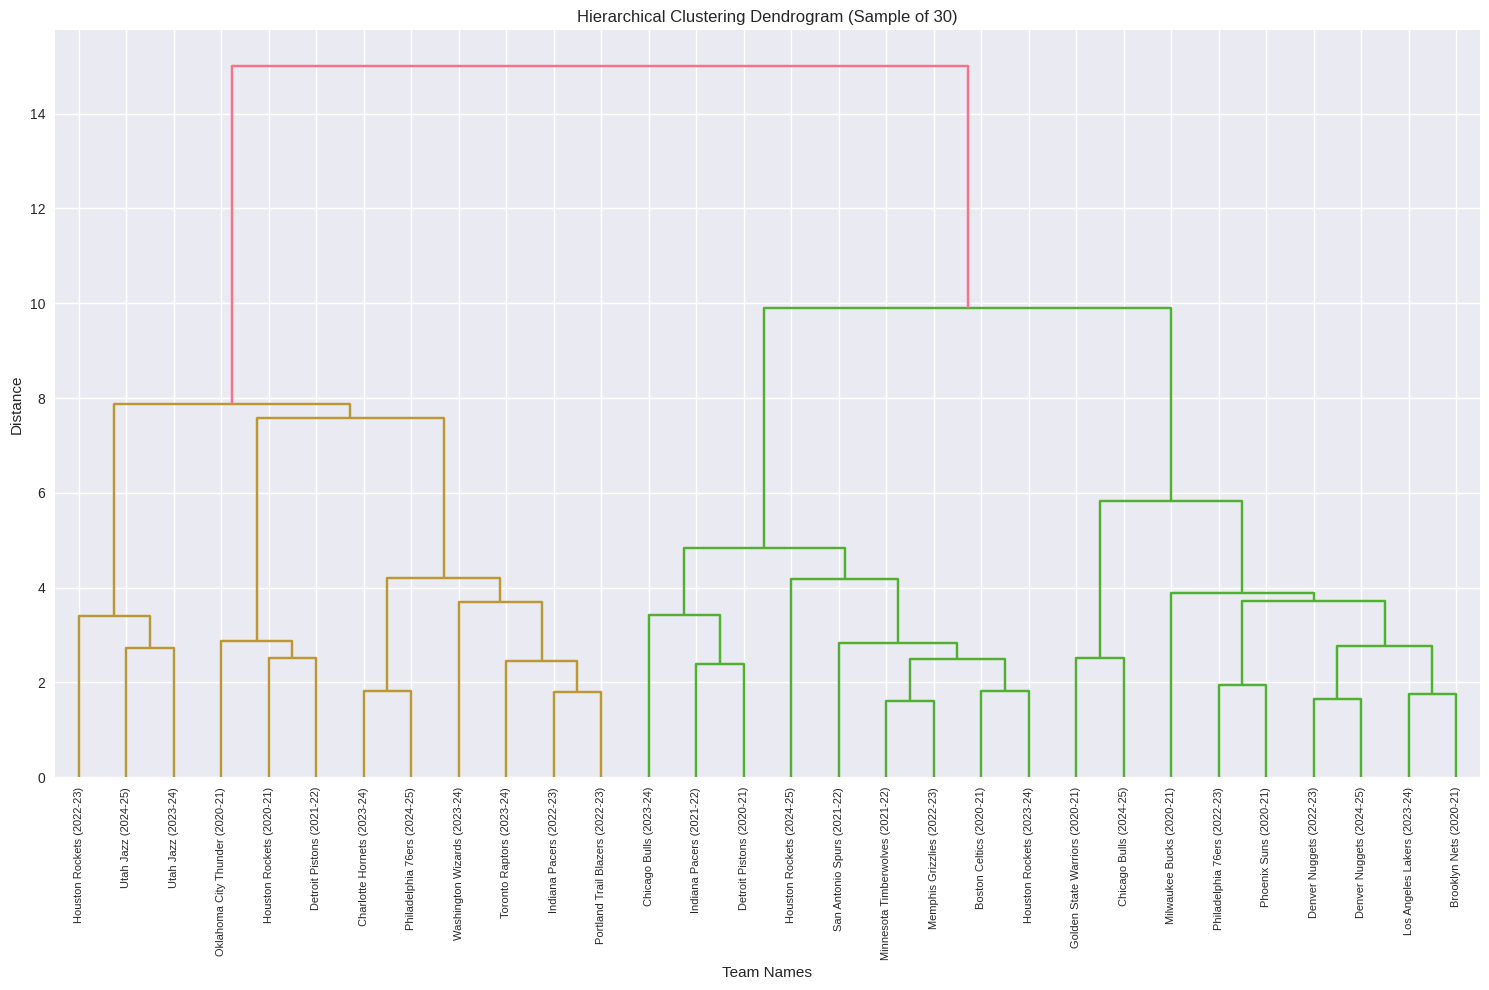

In [18]:
#!pip install nba_api
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nba_api.stats.endpoints import leaguedashteamstats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import DBSCAN
import warnings
from mpl_toolkits.mplot3d import Axes3D 

plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

SEASONS = ['2024-25', '2023-24', '2022-23', '2021-22', '2020-21']
FEATURES = [
    'OFF_RATING',
    'DEF_RATING',
    'NET_RATING',
    'PACE',
    'TS_PCT',
    'EFG_PCT',
    'AST_RATIO',
    'REB_PCT',
    'TM_TOV_PCT',
    'PIE'
]

def fetch_team_data(seasons=None):
    if seasons is None:
        seasons = SEASONS
        
    all_dfs = []
    
    for season in seasons:
        print(f"Fetching NBA team data for {season} (Advanced stats).")
        
        try:
            team_stats = leaguedashteamstats.LeagueDashTeamStats(
                season=season,
                season_type_all_star='Regular Season',
                measure_type_detailed_defense='Advanced'
            )
            
            df = team_stats.get_data_frames()[0]
            df['SEASON'] = season
            all_dfs.append(df)
        except Exception as e:
            print(f"Error fetching data for {season}: {e}")
            
    combined_df = pd.concat(all_dfs, ignore_index=True)
    print("All seasons retrieved successfully.")
    return combined_df

def prepare_data(df):
    df = df[['TEAM_NAME', 'SEASON', 'W_PCT'] + FEATURES].dropna()
    labels = df['W_PCT']
    
    df['WIN_TIER'] = pd.qcut(df['W_PCT'], 3, labels=['Low', 'Mid', 'High'])
    tier_labels = df['WIN_TIER']
    df['TEAM_NAME_SEASON'] = df['TEAM_NAME'] + ' (' + df['SEASON'] + ')'
    
    X = df[FEATURES]
    
    return X, labels, tier_labels, df['TEAM_NAME_SEASON'].values

def standardize_data(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    print("Means after scaling:", X_scaled.mean(axis=0))
    print("Std dev after scaling:", X_scaled.std(axis=0))
    
    return X_scaled

def apply_pca(X_scaled):
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_scaled)
    
    explained = pca.explained_variance_ratio_
    total_variance = explained.sum()
    
    print("Explained variance per component:", explained)
    print("Total variance retained:", total_variance)
    
    return X_pca, pca

def plot_raw_data(X, tier_labels):
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=X['OFF_RATING'], y=X['DEF_RATING'], hue=tier_labels)
    plt.title("Raw Data: OFF vs DEF Rating")
    plt.show()

def plot_pca_data(X_pca, tier_labels):
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=tier_labels)
    plt.title("PCA Reduced Data (2D View)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

def evaluate_kmeans(X_scaled):
    wcss = []
    k_range = range(1, 11)  
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_)
    
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, wcss, 'bo-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
    plt.title('Elbow Method for Optimal k')
    plt.grid(True)
    plt.show()
    
    print("Silhouette Scores:")
    for k in range(2, 8):
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        print(f"k={k}, silhouette={score:.3f}")

def perform_clustering(X_pca, X_scaled):
    print("Generating Elbow Plot:")
    evaluate_kmeans(X_scaled)

    optimal_k = 3  
    kmeans = KMeans(n_clusters=optimal_k, random_state=42)
    clusters_kmeans = kmeans.fit_predict(X_pca)
    
    # KMEANS
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_kmeans, alpha=0.7)
    plt.scatter(kmeans.cluster_centers_[:,0],
                kmeans.cluster_centers_[:,1],
                s=300, marker='X')
    plt.title("KMeans Clustering (Optimal k=3)")
    plt.show()
    
    # DBSCAN
    db = DBSCAN(eps=1.9, min_samples=5)
    clusters_dbscan = db.fit_predict(X_scaled)
    
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_dbscan)
    plt.title("DBSCAN Clustering")
    plt.show()

def plot_dendrogram(X_scaled, team_names, sample_size=30): 
    n_samples = len(X_scaled)
    team_name_list = list(team_names)
    
    indices = np.random.choice(n_samples, size=sample_size, replace=False)
    X_sample = X_scaled[indices]
    team_names_sample = [team_name_list[i] for i in indices]
    title_suffix = f" (Sample of {sample_size})"

    
    Z = linkage(X_sample, method='ward')
    
    plt.figure(figsize=(15, 10))
    dendrogram(Z, 
               labels=team_names_sample,
               p=5,
               leaf_rotation=90,
               leaf_font_size=8)
    plt.title(f"Hierarchical Clustering Dendrogram{title_suffix}")
    plt.xlabel("Team Names")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()

# Utilized GPT to help develop an eval function since initial testing of DBSCAN proved ineffective. I was having a hard time identifying
# the optimal parameters. 

def evaluate_dbscan(X_scaled):

    eps_values = np.arange(0.5, 3.0, 0.2)
    min_samples_values = [3, 4, 5, 6]

    for eps in eps_values:
        for min_s in min_samples_values:
            
            db = DBSCAN(eps=eps, min_samples=min_s)
            labels = db.fit_predict(X_scaled)
            
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            
            if n_clusters > 1:
                silhouette = silhouette_score(X_scaled, labels)
                print(f"eps={eps:.2f}, min_samples={min_s}, "
                      f"clusters={n_clusters}, noise={n_noise}, "
                      f"silhouette={silhouette:.3f}")

if __name__ == "__main__":
    warnings.filterwarnings("ignore")
    
    df = fetch_team_data()
    
    X, labels, tier_labels, team_names = prepare_data(df)
    
    print("\nOriginal Data Snapshot:")
    print(X.head())
    
    X_scaled = standardize_data(X)
    
    plot_raw_data(X, tier_labels)
    
    X_pca, pca = apply_pca(X_scaled)
    
    plot_pca_data(X_pca, tier_labels)
    
    perform_clustering(X_pca, X_scaled)
    
    plot_dendrogram(X_scaled, team_names)
